<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Amazon_Fine_Food_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Fine Food Reviews Analysis

This project explores the Amazon Fine Food Reviews dataset using pandas and basic NLP techniques.

Rather than focusing on classification performance, the analysis focuses on:
- review score distributions
- review length patterns
- helpful vs non-helpful reviews
- differences in language usage across review groups

The project combines exploratory data analysis (EDA) with simple text analysis methods such as CountVectorizer and TF-IDF to observe how review patterns differ depending on rating and helpfulness.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
print(os.listdir(path))

['hashes.txt', 'Reviews.csv', 'database.sqlite']


# ■ 데이터 확인

In [4]:
df = pd.read_csv(os.path.join(path, "Reviews.csv"))
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.shape

(568454, 10)

In [6]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [8]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


# ■ Score별 Review 관찰

In [9]:
df["Score"].value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


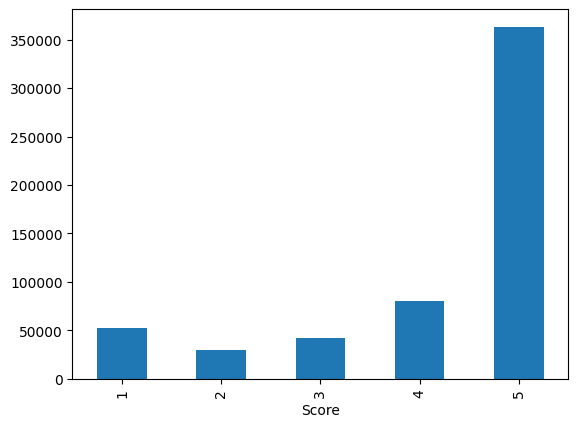

In [10]:
df["Score"].value_counts().sort_index().plot(kind="bar")
plt.show()

※ 5점이 대부분, 4점 > 1점 > 3점 > 2점 순이지만 미미함

## ■ Score별 Text length

In [11]:
df["review_length"] = df["Text"].str.len()
df[["Text", "review_length"]].head()

,Text,review_length
0,I have bought several of the Vitality canned d...,263
1,Product arrived labeled as Jumbo Salted Peanut...,190
2,This is a confection that has been around a fe...,509
3,If you are looking for the secret ingredient i...,219
4,Great taffy at a great price. There was a wid...,140


In [12]:
df.groupby("Score")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
Score,,,,,,,,
1,52268.0,478.082364,520.418149,12.0,202.0,338.0,563.0,11861.0
2,29769.0,490.655010,457.938943,33.0,212.0,357.0,605.0,9295.0
3,42640.0,520.319841,507.916337,32.0,214.0,374.0,656.0,21409.0
4,80655.0,496.603273,484.313327,35.0,196.0,347.0,623.0,12518.0
5,363122.0,402.447373,410.648076,18.0,170.0,277.0,481.0,16952.0


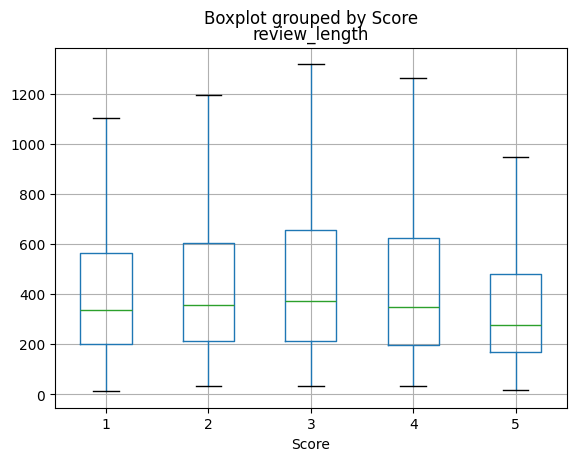

In [13]:
df.boxplot(column="review_length", by="Score", showfliers=False)
                                            # hide outliers
plt.show()

※ 5점 평점의 리뷰 길이가 전반적으로 가장 짧음.
- max는 긴 축이지만, 75%까지는 매우 낮은 축임을 고려할 때 대부분의 리뷰 길이가 짧으나 길이가 긴 outlier가 있어 보임
- 전반적으로 가장 긴 것은 3점 리뷰

In [ ]:
one_star = df[df["Score"]==1]
five_star = df[df["Score"]==5]

print(one_star["Text"].sample(5), end='\n')
print()
print(five_star["Text"].sample(5), end='\n')

352029    I purchased this tea because I was told that i...
317272    This juice is phenomenal--it's not the product...
142929    Muir Glen cans are lined in plastic and leach ...
432965    Given the price (3.50) I was expecting somethi...
491701    Just a gross coffee...horrible taste.  Ugh!  D...
Name: Text, dtype: object

457777    I love this and have ordered more. It has a ve...
343123    Just love this stuff.  It's a great size for t...
5825      Superior flavor, not too green, not too black....
298981    Who doesn't love chocolate? Who doesn't love c...
111739    These sticky traps work great and captured lot...
Name: Text, dtype: object


## ■ Score별 words count

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

In [20]:
vectorizer = CountVectorizer(
    stop_words = "english",
    max_features = 30,
    ngram_range = (1,2)
)   # 많이 등장한 단어 top 30

X_onestar = vectorizer.fit_transform(one_star["Text"])

words = vectorizer.get_feature_names_out()

counts_onestar = X_onestar.sum(axis=0).A1
                # 1차원으로

In [21]:
word_onestar_df = pd.DataFrame({
    "word" : words,
    "count" : counts_onestar
})

word_onestar_df.sort_values("count", ascending=False)

,word,count
5,br,65809
6,br br,26153
19,like,25770
21,product,23570
23,taste,18001
14,food,16959
17,just,16898
8,coffee,12459
15,good,11899
0,amazon,11880


In [22]:
X_fivestars = vectorizer.fit_transform(five_star["Text"])
counts_fivestars = X_fivestars.sum(axis=0).A1

In [23]:
word_fivestars_df = pd.DataFrame({
    "word" : words,
    "count" : counts_fivestars
})

word_fivestars_df.sort_values("count", ascending=False)

,word,count
3,bought,356428
4,box,140040
16,got,138076
14,food,128093
13,flavor,117622
15,good,101468
18,know,98859
7,buy,92792
21,product,91145
23,taste,90807


※ 별1개 리뷰, 별5개 리뷰 각각 vectorize
- bought : 별 5개에서 1위, 별 1개에서 하위
- br : 줄바꿈. 별 1개에서 상위이나 별 5개에서 하위
    - 별 5개 리뷰는 짧은 경향이 있어 줄바꿈이 자주 나타나지 않으나, 별 1개는 상대적으로 길기 때문에 자주 등장하는 것으로 추정
- like : 별 1개에서 상위라 특이
    - don't like 와 같이 결합될 것으로 추정됨

## ■ Score별 TF-IDF 차이 비교

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
vectorizer_tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 3000,
    ngram_range = (1,2)
)

In [26]:
X = vectorizer_tfidf.fit_transform(df["Text"])

In [28]:
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

In [30]:
neg_mean = X[(df["Score"] == 1).values].mean(axis=0).A1
pos_mean = X[(df["Score"] == 5).values].mean(axis=0).A1

In [32]:
diff = neg_mean - pos_mean
diff

array([ 0.00269724,  0.00184809,  0.00012067, ...,  0.00101822,
       -0.00023334, -0.00033947])

In [35]:
diff_df = pd.DataFrame({
    "feature" : feature_names_tfidf,
    "difference" : diff
})

diff_df.sort_values("difference", ascending=False).head(20)
# 부정적인 특징

,feature,difference
1740,money,0.014320
169,bad,0.012946
2062,product,0.012540
780,disappointed,0.011181
297,br,0.010743
2890,waste,0.010685
1326,horrible,0.009326
2891,waste money,0.009318
2959,worst,0.009242
2219,return,0.009144


In [36]:
diff_df.sort_values("difference", ascending=True).head(20)

,feature,difference
1185,great,-0.026164
1611,love,-0.019335
219,best,-0.015128
727,delicious,-0.011134
1142,good,-0.010320
1626,loves,-0.010160
1934,perfect,-0.009371
978,favorite,-0.009211
2650,tea,-0.009098
2427,snack,-0.007489


※ 단순 count보다 훨씬 더 부정적인/긍정적인 단어들을 잘 가져옴!

In [43]:
pd.set_option("display.max_colwidth", 150)
df[df["Text"].str.contains("waste money", case=False, na=False)][["Score", "Text"]].head(20)

,Score,Text
1417,2,Caviar taste awful. Maybe it's because I bought from a cheaper brand or maybe because cavier is just bad no matter who you buy it from or how much...
10073,4,These were a great quick snack that did not raise my blood sugar level and you could sprinkle a variety of seasons to your taste preferences. How...
21935,3,I bought 3 doggy products at the same time (all treat dispensing chew toys). This is my recommendation of the best product of the 3.<br /><br />I ...
31994,1,"My son loves pumpkin muffins. Can't find any Libby pumpkin in Cincinnati, OH. Tried this hoping it would be the same and it wasn't. Too much wa..."
36600,1,Gross!!!!They come in water. Smell like spoiled fish. Taste is horrible. I tried putting something on them and still tasted bad. Don't waste money...
39361,5,Vege-sal has been used in our home daily for decades. We love it in/on everything from soup to popcorn to scrambled eggs. I'm sorry to say that ...
43239,1,10 bucks a soda? Are you kidding? I can buy these at Wegman's for 2 bucks each. RIP OFF<br /><br />Why would anyone waste money on this?
50890,1,Very disappointed. Made my cat sick. Total waste of money. Back to just eating tuna for our girl. Can't afford to waste money.
60812,1,"I have been a Kashi customer for years since--literally since the 90s. While I love the cereal, and our family has eaten at least a box or two a ..."
68143,4,These were a great quick snack that did not raise my blood sugar level and you could sprinkle a variety of seasons to your taste preferences. How...


# ■ Helpful Reviews

In [53]:
df["HelpfulnessDenominator"].value_counts()

,count
HelpfulnessDenominator,
0,270052
1,112753
2,61482
3,34394
4,22306
...,...
256,1
251,1
195,1


In [54]:
df["HelpfulnessNumerator"].value_counts()

,count
HelpfulnessNumerator,
0,303826
1,116467
2,53727
3,29007
4,16963
...,...
109,1
281,1
231,1


In [52]:
df["helpfulness_ratio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"],
    0
)

df["helpfulness_ratio"].head()

,helpfulness_ratio
0,1.0
1,0.0
2,1.0
3,1.0
4,0.0


In [56]:
df["helpfulness_ratio"].value_counts()

,count
helpfulness_ratio,
0.000000,303826
1.000000,183309
0.500000,21623
0.666667,10514
0.750000,6364
...,...
0.995000,1
0.990291,1
0.996894,1


In [16]:
high_help = df[df["helpfulness_ratio"] > 0.9]
low_help = df[df["helpfulness_ratio"] < 0.3]

for i in range(5):
    print(high_help["Text"].iloc[i], end='\n')

I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.
Right 

※ helpfulness_ratio가 높은 리뷰는 일반적이기보다 구체적임

In [17]:
high_help_len = high_help["Text"].str.len()
low_help_len = low_help["Text"].str.len()
print(high_help_len.mean())
print(low_help_len.mean())

486.80043023058664
382.7301162383384


- high help 리뷰 길이 : 486.80043023058664
- low help 리뷰 길이: 382.7301162383384
- high help 리뷰의 길이가 확연히 길다

## ■ Helpful Reviews TF-IDF

In [45]:
high_help_mean = X[(df["helpfulness_ratio"] > 0.9).values].mean(axis=0).A1
low_help_mean = X[(df["helpfulness_ratio"] < 0.3).values].mean(axis=0).A1

In [46]:
diff_help = (high_help_mean) - (low_help_mean)

In [47]:
diff_help_df = pd.DataFrame({
    "feature" : feature_names_tfidf,
    "difference" : diff_help
})

diff_help_df.sort_values("difference", ascending=False).head(20)

,feature,difference
297,br,0.013000
1053,food,0.007308
301,br br,0.006651
441,cat,0.003435
1828,oil,0.003354
2837,ve,0.003224
2815,use,0.002746
2980,years,0.002511
2650,tea,0.002225
2226,rice,0.002124


In [48]:
diff_help_df.sort_values("difference", ascending=True).head(20)

,feature,difference
539,coffee,-0.008733
2763,treats,-0.002359
1611,love,-0.002237
1142,good,-0.002134
2427,snack,-0.002086
1626,loves,-0.001842
2762,treat,-0.001479
2548,strong,-0.001458
1022,flavor,-0.001420
1185,great,-0.001402


- Helpful한 Reviews와 그렇지 않은 것 사이 단어상 큰 차이는 없지만,
    - br(줄바꿈) 이 helpful한 리뷰의 상위인 것을 볼 때, helpful reviews에서 줄바꿈이 더 특징적임 > 길이가 더 길다고 추측 가능
- 무관할 수 있으나, helpful한 리뷰에서 특징적인 품목은 'oil', 'rice', 'tea', 'salt', 'organic'
    - helpful하지 않은 리뷰에서 언급되는 품목은 'coffee', 'snack', 'cereal', 'chips', 'cookies' 등
    - 연관 있는지는 모르겠지만 흥미로움

In [50]:
df[df["Text"].str.contains("oil", case=False, na=False)][["Score", "Text", "helpfulness_ratio"]].head(20)

,Score,Text,helpfulness_ratio
32,4,McCann's Instant Oatmeal is great if you must have your oatmeal but can only scrape together two or three minutes to prepare it. There is no escap...,1.0
40,5,"The variety packs taste great!<br /><br />I have them every morning. At $0.30 cents per meal, I don't understand why everyone on earth isn't buyin...",0.0
66,5,For those of us on a low carb diet these little tablets are just the thing.<br /><br />Two years ago I started cycling again after many years but ...,0.0
82,5,"I know the product title says Molecular Gastronomy, but don't let that scare you off. I have been looking for this for a while now, not for food ...",1.0
105,5,I like Creme Brulee. I loved that these were so easy. Just sprinkle on the sugar that came with and broil. They look amazing and taste great. My g...,0.0
217,3,My husband and I are both kind of wimpy when it comes to hot things and this seasoning is just a bit too spicy for us. It definitely makes you swe...,0.0
257,1,I so wish I would have read this review before purchasing TWO gallons of this oil for my health issues. It reeks like a chemical rubber smell. Thi...,1.0
258,2,This product has a strong after-taste of Crayola crayons!<br /><br />I am in the process of trying different brands of coconut oils for cooking pu...,1.0
269,4,"This is a delicious sugar. It has a pretty light brown color and delicious aroma. But the granules are quite big, however -- bigger than plain ref...",0.0
308,5,"Try this you might like it. I did and I am quite addicted, it is too easy to prepare, it tastes great and it absorbs the flavors you cook it with....",1.0


In [58]:
df[df["Text"].str.contains("coffee", case=False, na=False)][["Score", "Text", "helpfulness_ratio"]].head(20)

,Score,Text,helpfulness_ratio
30,5,"I have never been a huge coffee fan. However, my mother purchased this little machine and talked me into trying the Latte Macciato. No Coffee Shop...",0.000000
38,4,"I WAS VISITING MY FRIEND NATE THE OTHER MORNING FOR COFFEE , HE CAME OUT OF HIS STORAGE ROOM WITH ( A PACKET OF McCANNS INSTANT IRISH OATMEAL .) H...",0.000000
54,4,"I roast at home with a stove-top popcorn popper (but I do it outside, of course). These beans (Coffee Bean Direct Green Mexican Altura) seem to be...",1.000000
55,5,We roast these in a large cast iron pan on the grill (about 1/3 of the bag at a time). The smell is wonderful and the roasted beans taste delicio...,0.000000
82,5,"I know the product title says Molecular Gastronomy, but don't let that scare you off. I have been looking for this for a while now, not for food ...",1.000000
111,5,I have been drinking this tea for a long time now. I used to have to purchase it at a doctor's office because it wasn't available elsewhere. I'm...,1.000000
112,5,I have been drinking Royal King 100% Natural Organic Green Tea (100 tea bags x 2g each) as my every day tea for several years now. I buy 12 boxes...,1.000000
153,1,These singles sell for $2.50 - $3.36 at the store for 1 box of 24 singles. I'm not sure why Amazon is selling it for $9.99 for a box of 24 singles...,1.000000
171,5,I have drunk Ricore since my mother allowed be to drink caffeine. I love this stuff in milk.<br />It's much smoother and tastier than instant coff...,1.000000
173,5,"I couldn't wait to try the 8&#8243; Cinnamon Coffee Cake because it is made with fresh eggs, creamy sour cream, Madagascar Bourbon Vanilla and is ...",0.000000


#■ Conclusion

Several interesting patterns appeared during the analysis.

Positive reviews were overwhelmingly more common, while lower-rated reviews tended to be longer and more detailed. Reviews marked as helpful were also generally longer and contained more specific descriptions of products and user experiences.

Simple word frequency comparisons did not show strong distinctions between positive and negative reviews. However, TF-IDF-based comparisons highlighted more characteristic positive and negative expressions.

Some unexpected differences also appeared between helpful and non-helpful reviews, including differences in product-related vocabulary. Although the relationship was not always clear, the analysis showed that combining text features with metadata can reveal interesting patterns in user reviews.

Overall, this project focused more on exploratory corpus analysis and interpretation rather than predictive modeling.